<b>Helping a cousin with University admission </b>

In this notebook, we predict student admissions to graduate school at UCLA based on three pieces of data:

    GRE Scores (Test)
    GPA Scores (Grades)
    Class rank (1-4)

The dataset originally came from here: http://www.ats.ucla.edu/

Loading the data

To load the data and format it nicely, we will use two very useful packages called Pandas and Numpy. 

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# Reading the csv file into a pandas DataFrame
data = pd.read_csv('student_data.csv')

# Printing out the first 5 rows of our data
data.head()

,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


In [3]:
#Check the number of rows and columns in the data
data.shape

(400, 4)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    int64  
 1   gre     400 non-null    int64  
 2   gpa     400 non-null    float64
 3   rank    400 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 12.6 KB


In [5]:
data.describe()

,admit,gre,gpa,rank
count,400.000000,400.000000,400.000000,400.00000
mean,0.317500,587.700000,3.389900,2.48500
std,0.466087,115.516536,0.380567,0.94446
min,0.000000,220.000000,2.260000,1.00000
25%,0.000000,520.000000,3.130000,2.00000
50%,0.000000,580.000000,3.395000,2.00000
75%,1.000000,660.000000,3.670000,3.00000
max,1.000000,800.000000,4.000000,4.00000


- The old format of the GRE General Test, used before August 1, 2011, had a maximum possible score of 800 for each of its two main sections (Verbal Reasoning and Quantitative Reasoning). 

In [15]:
# Check for null values
data.isnull().sum()

admit    0
gre      0
gpa      0
rank     0
dtype: int64


<b>Plotting the data</b>

First let's make a plot of our data to see how it looks. In order to have a 2D plot, let's ignore the rank.


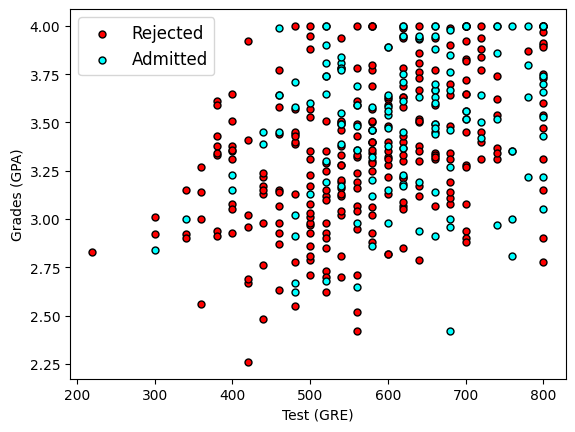

In [17]:
# %matplotlib inline
import matplotlib.pyplot as plt

# Function to help us plot
def plot_points(data):
    X = np.array(data[["gre","gpa"]])
    y = np.array(data["admit"])
    admitted = X[np.argwhere(y==1)]
    rejected = X[np.argwhere(y==0)]
    plt.scatter([s[0][0] for s in rejected], [s[0][1] for s in rejected], s = 25, color = 'red', edgecolor = 'k')
    plt.scatter([s[0][0] for s in admitted], [s[0][1] for s in admitted], s = 25, color = 'cyan', edgecolor = 'k')
    plt.xlabel('Test (GRE)')
    plt.ylabel('Grades (GPA)')
    
# Plotting the points
plot_points(data)
plt.legend(["Rejected", "Admitted"], fontsize="large")
plt.show()

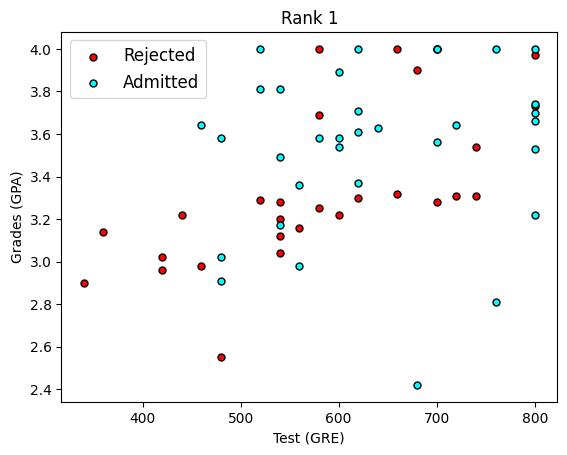

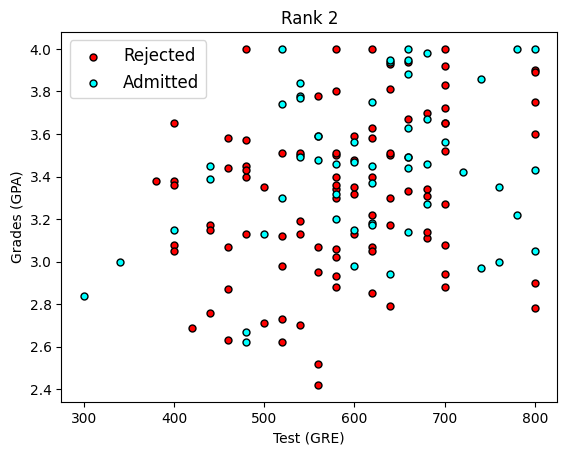

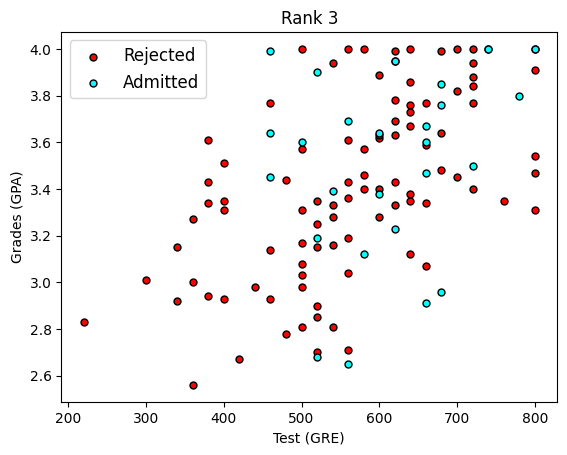

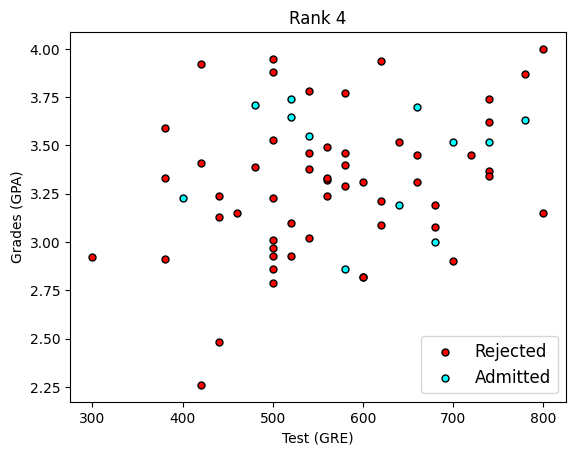

In [22]:
# Separating the ranks
data_rank1 = data[data["rank"]==1]
data_rank2 = data[data["rank"]==2]
data_rank3 = data[data["rank"]==3]
data_rank4 = data[data["rank"]==4]

# Plotting the graphs
plot_points(data_rank1)
plt.title("Rank 1")
plt.legend(["Rejected", "Admitted"], fontsize="large")
plt.show()
plot_points(data_rank2)
plt.title("Rank 2")
plt.legend(["Rejected", "Admitted"], fontsize="large")
plt.show()
plot_points(data_rank3)
plt.title("Rank 3")
plt.legend(["Rejected", "Admitted"], fontsize="large")
plt.show()
plot_points(data_rank4)
plt.title("Rank 4")
plt.legend(["Rejected", "Admitted"], fontsize="large")
plt.show()

## One-hot encoding the rank

Use the get_dummies function in pandas in order to one-hot encode the data.

In [23]:
df = pd.get_dummies(data, columns=['rank'], dtype=float, drop_first=True)

In [24]:
df.head()

,admit,gre,gpa,rank_2,rank_3,rank_4
0,0,380,3.61,0.0,1.0,0.0
1,1,660,3.67,0.0,1.0,0.0
2,1,800,4.00,0.0,0.0,0.0
3,1,640,3.19,0.0,0.0,1.0
4,0,520,2.93,0.0,0.0,1.0


In [25]:
# Separate features and target
X = df.drop('admit', axis=1)
y = df['admit']

In [26]:
# Understand the distribution of the target feature
y.value_counts(normalize=True)

admit
0    0.6825
1    0.3175
Name: proportion, dtype: float64

In [27]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [31]:
# Normalize numerical features using MinMaxScaler
num_features = ['gre', 'gpa']
scaler = MinMaxScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

In [37]:
# Convert to tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

In [38]:
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [40]:
# Define a simple neural network in PyTorch
input_dim = X_train.shape[1] #extract the number of features from the dataset
model = nn.Sequential(
    nn.Linear(input_dim, 8),
    nn.ReLU(), # max(0, z)
    nn.Linear(8, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

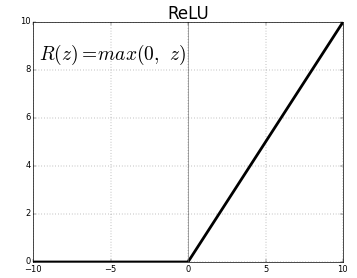

In [26]:
model

Sequential(
  (0): Linear(in_features=5, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)

In [13]:
# Train the model
epochs = 200
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    # Optional: print trace every 5 epochs
    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            outputs = torch.sigmoid(outputs)
            preds = (outputs >= 0.5).float()
            acc = (preds == y_train_tensor).float().mean().item()
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Train Acc: {acc:.4f}")

Epoch 5/200, Loss: 0.7069, Train Acc: 0.3187
Epoch 10/200, Loss: 0.6824, Train Acc: 0.6812
Epoch 15/200, Loss: 0.6622, Train Acc: 0.6812
Epoch 20/200, Loss: 0.6433, Train Acc: 0.6812
Epoch 25/200, Loss: 0.6305, Train Acc: 0.6812
Epoch 30/200, Loss: 0.6270, Train Acc: 0.6812
Epoch 35/200, Loss: 0.6268, Train Acc: 0.6812
Epoch 40/200, Loss: 0.6239, Train Acc: 0.6812
Epoch 45/200, Loss: 0.6202, Train Acc: 0.6812
Epoch 50/200, Loss: 0.6177, Train Acc: 0.6812
Epoch 55/200, Loss: 0.6158, Train Acc: 0.6812
Epoch 60/200, Loss: 0.6136, Train Acc: 0.6812
Epoch 65/200, Loss: 0.6112, Train Acc: 0.6812
Epoch 70/200, Loss: 0.6087, Train Acc: 0.6812
Epoch 75/200, Loss: 0.6061, Train Acc: 0.6812
Epoch 80/200, Loss: 0.6034, Train Acc: 0.6812
Epoch 85/200, Loss: 0.6006, Train Acc: 0.6812
Epoch 90/200, Loss: 0.5980, Train Acc: 0.6812
Epoch 95/200, Loss: 0.5949, Train Acc: 0.6812
Epoch 100/200, Loss: 0.5926, Train Acc: 0.6812
Epoch 105/200, Loss: 0.5902, Train Acc: 0.6812
Epoch 110/200, Loss: 0.5878, Trai

In [29]:
torch.save(model, 'admissions_model_full.pt')

print("Saved model files: admissions_model_full.pt")

Saved model files: admissions_model_full.pt


In [28]:
new_samples = pd.DataFrame([
    {'gre': 750, 'gpa': 3.8, 'rank': 2},
    {'gre': 660, 'gpa': 3.67, 'rank': 3},
])
numeric = new_samples[num_features]
numeric_scaled = scaler.transform(numeric) 
numeric_scaled_df = pd.DataFrame(numeric_scaled, columns=["gre_scaled", "gpa_scaled"], index=new_samples.index)
    
# Categorical one-hot
dummies = pd.get_dummies(new_samples["rank"], prefix="rank", dtype=float, drop_first=True)
# Ensure consistent rank columns even if some categories don't appear
rank_cols = [f"rank_{i}" for i in [2, 3, 4]]
rank_ohe = dummies.reindex(columns=rank_cols, fill_value=0)

# Final feature order: gre_scaled, gpa_scaled, rank_1, rank_2, rank_3, rank_4
X_new = pd.concat([numeric_scaled_df, rank_ohe], axis=1)
X_new_tensor = torch.tensor(X_new.values, dtype=torch.float32)

with torch.no_grad():
    new_logits = model(X_new_tensor)
    new_probs = torch.sigmoid(new_logits).cpu().numpy().ravel()
    new_preds = (new_probs >= 0.5).astype(int)

for i, row in new_samples.iterrows():
    print(f"\nSample {i+1}: {dict(row)}")
    print(f"Predicted Admit Probability: {new_probs[i]:.3f}")
    print(f"Predicted Admit Class (0=no, 1=yes): {new_preds[i]}")


Sample 1: {'gre': np.float64(750.0), 'gpa': np.float64(3.8), 'rank': np.float64(2.0)}
Predicted Admit Probability: 0.509
Predicted Admit Class (0=no, 1=yes): 1

Sample 2: {'gre': np.float64(660.0), 'gpa': np.float64(3.67), 'rank': np.float64(3.0)}
Predicted Admit Probability: 0.292
Predicted Admit Class (0=no, 1=yes): 0


#To DO Assigmnet

Write inference code to classify and calculate accuracy on the test set
